#  Bank Marketing Campaign Response Prediction


Banks invest heavily in marketing to win new term-deposit customers. This predictor helps improve campaign efficiency by estimating early whether a contacted customer is likely to subscribe, so the bank can focus time and budget on the most promising leads.

The dataset is [Bank Marketing (from UCI)](https://archive.ics.uci.edu/dataset/222/bank+marketing), with 41,128 entries and 21 attributes.

Attributes

- 1 age 
- job: type of job 
- marital
- education
- default: has credit in default
- balance: average yearly balance, in euros
- housing: has housing loan?
- loan: has personal loan?

Related to the last contact of the current campaign

- contact: contact communication type
- day: last contact day of the month
- month: last contact month of year
- duration: last contact duration, in seconds

Other attributes

- campaign: number of contacts performed during this campaign and for this client
- pdays: number of days since the client was last contacted from a previous campaign (numeric, -1 means not previously contacted)
- previous: number of contacts performed before this campaign and for this client
- poutcome: outcome of the previous marketing campaign

Output variable (target)

- y: has the client subscribed a term deposit? (binary: "yes","no")

Economic indicators

emp.var.rate (Employment Variation Rate): measures whether employment is increasing or decreasing.

Positive value: more people getting jobs
Negative value: more people losing jobs
cons.price.idx (Consumer Price Index): measures average price of goods and services (inflation indicator).

Higher CPI: higher prices
Lower CPI: lower prices
euribor3m (3-Month Euribor Rate): a major European interest rate benchmark (market interest level).

nr.employed (Number of Employees): total number of employed people in the economy

In [152]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [154]:
df.shape

(41188, 21)

In [155]:

pd.set_option('display.max_columns', None)

df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [157]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [158]:
df.duplicated().sum()

np.int64(12)

In [159]:
df = df.drop_duplicates()

In [160]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [161]:
df["pdays"].value_counts().head(10)

,count
pdays,
999,39661
3,439
6,412
4,118
9,64
2,61
7,60
12,58
10,52


In [162]:
(df["pdays"] == 999).mean() * 100

np.float64(96.32067223625413)

In [163]:
df["previously_contacted"] = (df["pdays"] != 999)

In [164]:
pd.crosstab(
    df["previously_contacted"],
    df["y"],
    normalize="index"
)

y,no,yes
previously_contacted,,
False,0.907415,0.092585
True,0.361716,0.638284


This suggests that prior interaction with the customer is one of the strongest indicators of success.

In [165]:
for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print((df[col] == "unknown").sum())


job
330

marital
80

education
1730

default
8596

housing
990

loan
990

contact
0

month
0

day_of_week
0

poutcome
0

y
0


The bank does not know this information and it may be helpful as during promotional campaigns, banks may not have complete user data and keeping such data as it is may give more factual insights.

In [166]:
pd.crosstab(
    df["education"],
    df["y"],
    normalize="index"
)

y,no,yes
education,,
basic.4y,0.897510,0.102490
basic.6y,0.917940,0.082060
basic.9y,0.921754,0.078246
high.school,0.891611,0.108389
illiterate,0.777778,0.222222
professional.course,0.886450,0.113550
university.degree,0.862792,0.137208
unknown,0.854913,0.145087


Unknown education has higher subscription rate than almost every known education category.

In [167]:
df["education"].value_counts()

,count
education,
university.degree,12164
high.school,9512
basic.9y,6045
professional.course,5240
basic.4y,4176
basic.6y,2291
unknown,1730
illiterate,18


Although the illiterate category showed the highest subscription rate (22.2%), it contained only 18 observations and therefore does not provide reliable evidence of a true pattern.

In [168]:
pd.crosstab(
    df["default"],
    df["y"],
    normalize="index"
)

y,no,yes
default,,
no,0.871197,0.128803
unknown,0.948464,0.051536
yes,1.000000,0.000000


In [169]:
pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
)

y,no,yes
job,,
admin.,0.870333,0.129667
blue-collar,0.931049,0.068951
entrepreneur,0.914835,0.085165
housemaid,0.900000,0.100000
management,0.887825,0.112175
retired,0.747381,0.252619
self-employed,0.895144,0.104856
services,0.918578,0.081422
student,0.685714,0.314286


Subscription rates vary substantially across occupational groups. Students (31.4%) and retired customers (25.3%) exhibit the highest subscription rates, while blue-collar workers show the lowest rate (6.9%). This suggests that occupation is an important factor influencing a customer's likelihood of subscribing to a term deposit.

As the data contains unknown values in multiple attributes, but they are needed for prediction, we will keep it and not remove it.

The data is pretty much clean.


<Axes: xlabel='y', ylabel='count'>

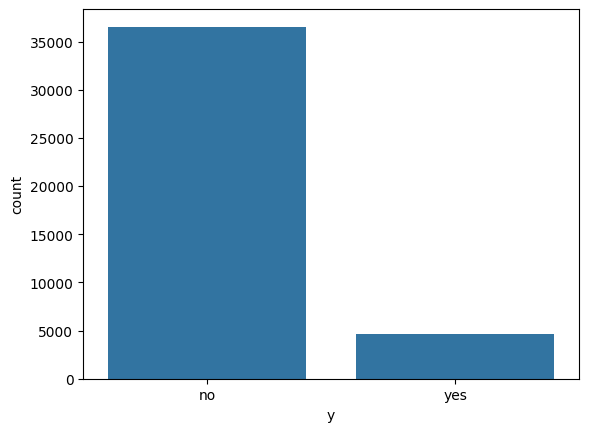

In [170]:
sns.countplot(x='y', data=df)

In [172]:
df["y"].value_counts()

,count
y,
no,36537
yes,4639




The target variable is highly imbalanced, with the majority of customers not subscribing to a term deposit. This imbalance may bias machine learning models toward the majority class and therefore requires special handling during model development.

This shows that around 1 in 7 customers subscribe. Marketing resources should be more focused on high probability customers.

<Axes: xlabel='poutcome'>

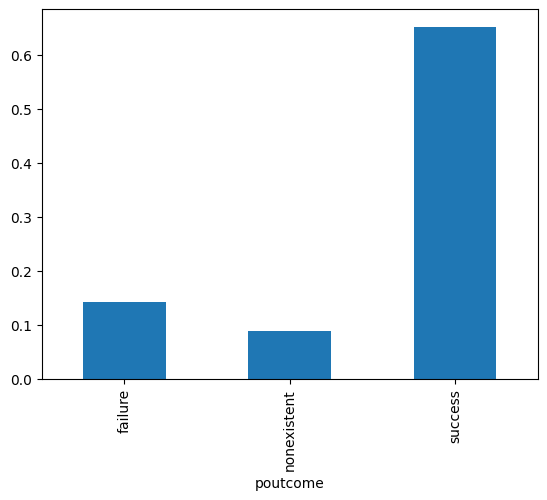

In [173]:
pout = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
)

pout["yes"].plot(kind="bar")

Customers who previously responded successfully are the highest-value leads and should be prioritized.

<Axes: xlabel='previously_contacted'>

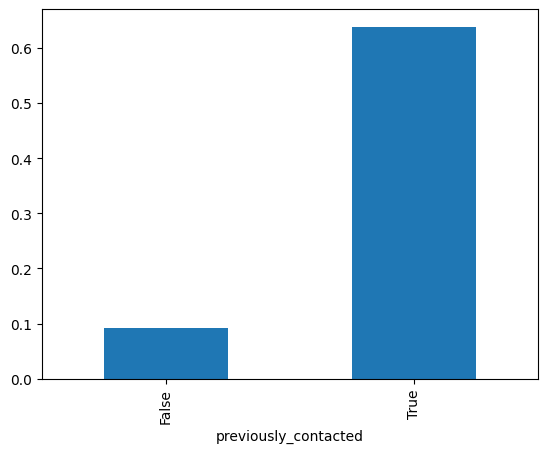

In [174]:
prev = pd.crosstab(
    df["previously_contacted"],
    df["y"],
    normalize="index"
)

prev["yes"].plot(kind="bar")

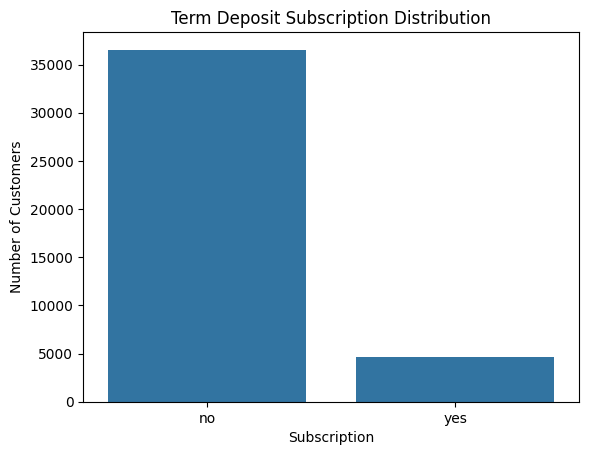

In [175]:
sns.countplot(x="y", data=df)

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.show()

Existing relationships dramatically improve conversion rates.

<Axes: xlabel='month'>

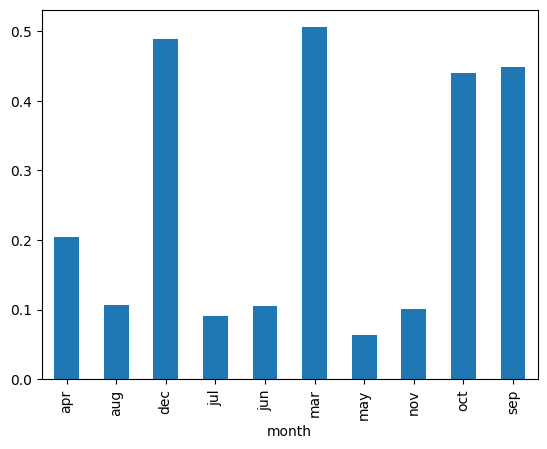

In [176]:
month = pd.crosstab(
    df["month"],
    df["y"],
    normalize="index"
)

month["yes"].plot(kind="bar")

Campaign timing matters. Concentrate marketing efforts during high-performing months.

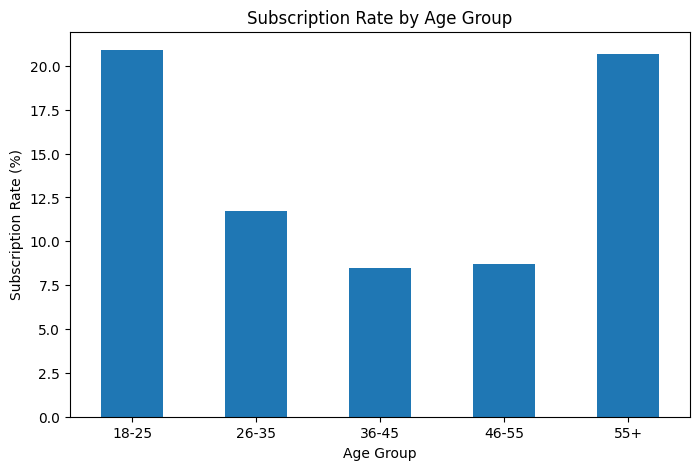

In [216]:
# Create Age Groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "55+"
    ]
)

# Subscription Rate by Age Group
age_sub = pd.crosstab(
    df["age_group"],
    df["y"],
    normalize="index"
)

# Convert to percentage and plot
(age_sub["yes"] * 100).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=0)

plt.show()

Customers aged 18 - 25 and above 55 years exhibit the highest subscription rates, while customers between 26 and 55 years show significantly lower conversion rates. Marketing campaigns may therefore achieve higher effectiveness when targeted toward younger and older customer segments.

<Axes: xlabel='y', ylabel='duration'>

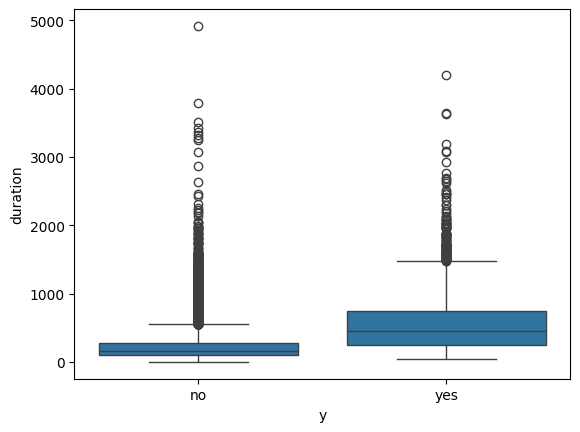

In [178]:
sns.boxplot(
    data=df,
    x="y",
    y="duration"
)

Subscribers generally have much longer call durations.

In [180]:
df["y_encoded"] = df["y"].map({"no":0, "yes":1})

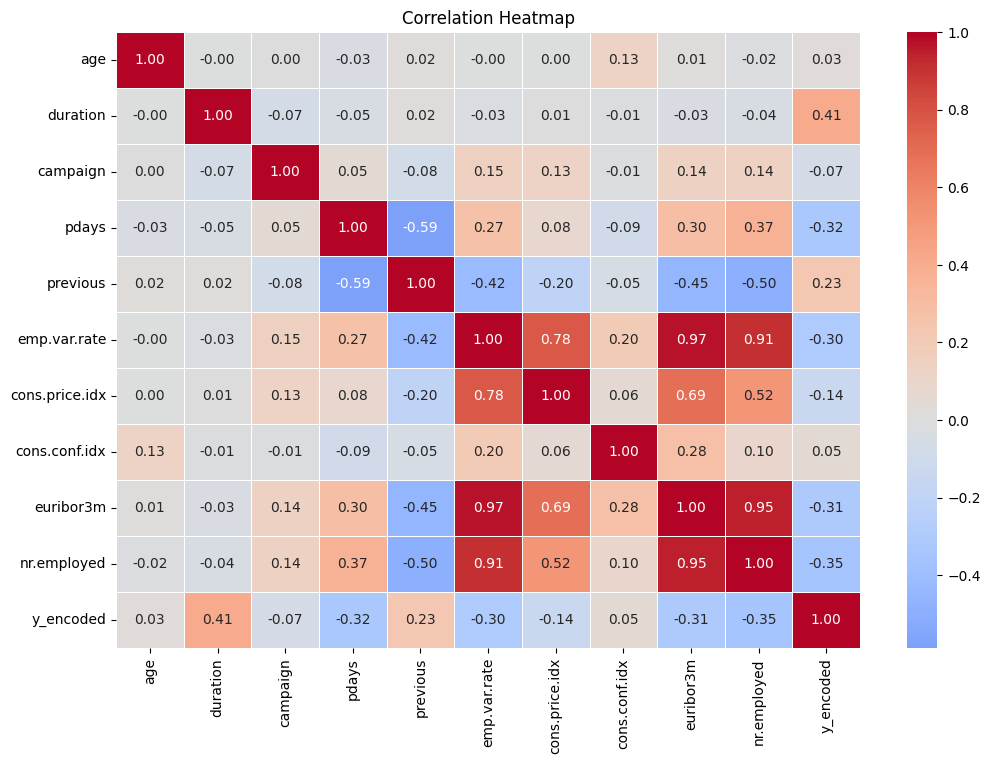

In [214]:
# Select only numeric columns
corr = df.select_dtypes(include="number").corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Economic conditions have a strong impact on customer behavior. Interest rates and labor market conditions tend to improve or deteriorate together, influencing customers' willingness to invest in term deposits.


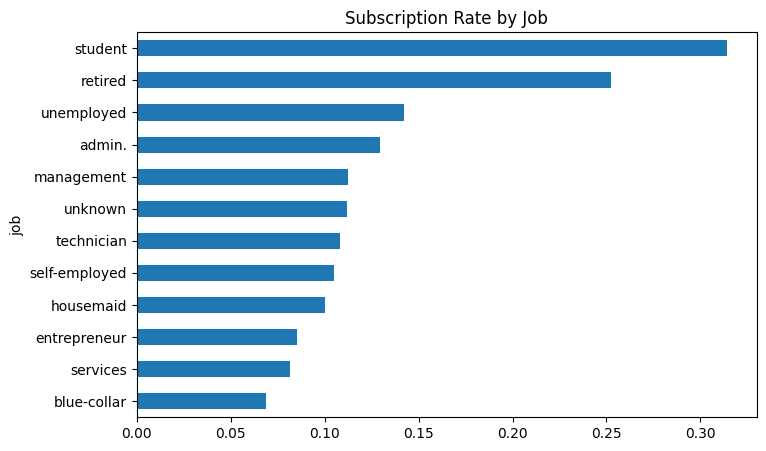

In [182]:
job_sub = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
)

job_sub["yes"].sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Subscription Rate by Job")
plt.show()



Customers from different job categories show different subscription rates.

Students and retired customers are more likely to subscribe, whereas blue-collar and service workers are less likely to subscribe.

This indicates that the `job` feature contains useful information for predicting customer subscription behavior.

y               no       yes
marital                     
divorced  0.896769  0.103231
married   0.898439  0.101561
single    0.859910  0.140090
unknown   0.850000  0.150000


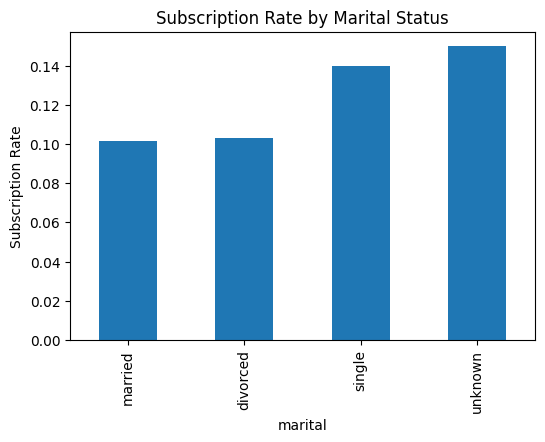

In [183]:
marital_sub = pd.crosstab(
    df["marital"],
    df["y"],
    normalize="index"
)

print(marital_sub)

marital_sub["yes"].sort_values().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Subscription Rate by Marital Status")
plt.ylabel("Subscription Rate")
plt.show()

y              no       yes
housing                    
no       0.891217  0.108783
unknown  0.891919  0.108081
yes      0.883779  0.116221


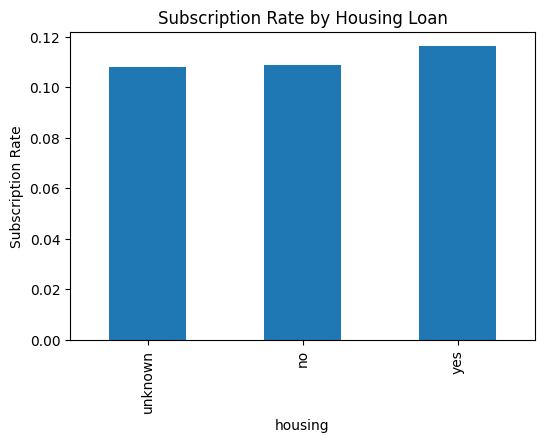

In [184]:
housing_sub = pd.crosstab(
    df["housing"],
    df["y"],
    normalize="index"
)

print(housing_sub)

housing_sub["yes"].sort_values().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Subscription Rate by Housing Loan")
plt.ylabel("Subscription Rate")
plt.show()

y              no       yes
loan                       
no       0.886587  0.113413
unknown  0.891919  0.108081
yes      0.890685  0.109315


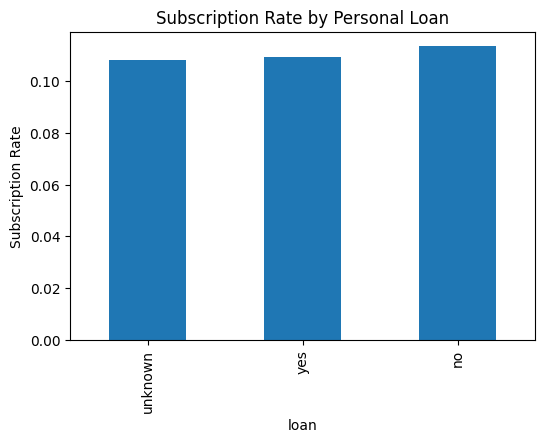

In [185]:
loan_sub = pd.crosstab(
    df["loan"],
    df["y"],
    normalize="index"
)

print(loan_sub)

loan_sub["yes"].sort_values().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Subscription Rate by Personal Loan")
plt.ylabel("Subscription Rate")
plt.show()

As Euribor increases, the probability of subscription tends to decrease.

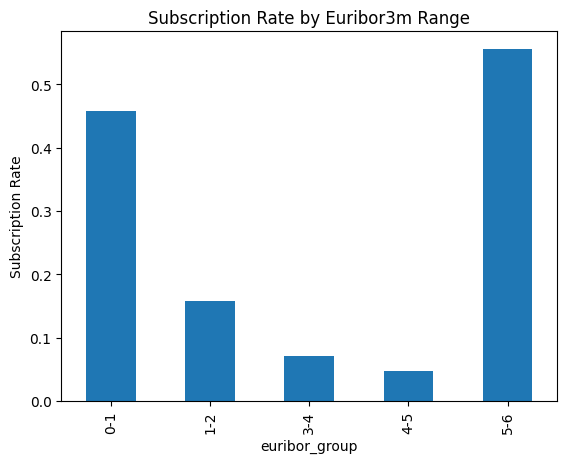

In [186]:
df["euribor_group"] = pd.cut(
    df["euribor3m"],
    bins=[0,1,2,3,4,5,6],
    labels=["0-1","1-2","2-3","3-4","4-5","5-6"]
)

euribor_sub = pd.crosstab(
    df["euribor_group"],
    df["y"],
    normalize="index"
)

euribor_sub["yes"].plot(kind="bar")

plt.title("Subscription Rate by Euribor3m Range")
plt.ylabel("Subscription Rate")
plt.show()

Several features such as `marital`, `housing`, and `loan` showed very little variation in subscription rates across their categories during exploratory analysis.

Since these variables demonstrated weak individual relationships with the target variable and did not provide strong discriminatory power, they were not included in the final feature set.

As a result, features such as `age`, `job`, `contact`, `campaign`, `previous`, `poutcome`, `euribor3m`, and `duration` were retained for model development.

In [187]:
features = [
    "age",
    "job",
    "contact",
    "campaign",
    "previous",
    "poutcome",
    "euribor3m",
    "duration"
]

X = df[features]
y = df["y"]

After completing data cleaning, and  data analysis, the next step is to train machine learning models.

The goal is to predict whether a customer will subscribe to a term deposit using the selected features.

Based on the insights from EDA, the following features were chosen for model training:

- Age
- Job
- Contact Method
- Campaign Contacts
- Previous Campaign Information
- Previous Campaign Outcome
- Euribor 3-Month Rate
- Call Duration

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["age","campaign","previous","euribor3m","duration"]

cat_cols = ["job", "contact", "poutcome"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

## Data Preprocessing

The dataset contains both numerical and categorical features.

Before training the models:

- Numerical features (`age`, `campaign`, `previous`, `euribor3m`, `duration`) are scaled using StandardScaler.
- Categorical features (`job`, `contact`, `poutcome`) are converted into numerical format using One-Hot Encoding.

A Column Transformer is used to apply the appropriate preprocessing steps to each feature type.

Logistic Regression


In [190]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

log_pipeline.fit(X_train, y_train)

y_pred_log = log_pipeline.predict(X_test)

In [191]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

          no       0.93      0.97      0.95      7308
         yes       0.65      0.38      0.48       928

    accuracy                           0.91      8236
   macro avg       0.79      0.68      0.72      8236
weighted avg       0.90      0.91      0.90      8236



Decision Tree Classifier


In [192]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

          no       0.95      0.96      0.95      7308
         yes       0.62      0.58      0.60       928

    accuracy                           0.91      8236
   macro avg       0.79      0.77      0.78      8236
weighted avg       0.91      0.91      0.91      8236



Random Forest Classifier

In [193]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          no       0.94      0.96      0.95      7308
         yes       0.63      0.49      0.55       928

    accuracy                           0.91      8236
   macro avg       0.79      0.73      0.75      8236
weighted avg       0.90      0.91      0.91      8236



XGB Classifier

In [194]:
from xgboost import XGBClassifier

y_train_xgb = y_train.map({"no":0, "yes":1})
y_test_xgb = y_test.map({"no":0, "yes":1})

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train_xgb)

y_pred_xgb = xgb_pipeline.predict(X_test)

In [195]:
from sklearn.metrics import classification_report

print(classification_report(y_test_xgb, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.67      0.55      0.61       928

    accuracy                           0.92      8236
   macro avg       0.81      0.76      0.78      8236
weighted avg       0.91      0.92      0.92      8236



In [196]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_xgb, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, pos_label="yes"),
        precision_score(y_test, y_pred_dt, pos_label="yes"),
        precision_score(y_test, y_pred_rf, pos_label="yes"),
        precision_score(y_test_xgb, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, pos_label="yes"),
        recall_score(y_test, y_pred_dt, pos_label="yes"),
        recall_score(y_test, y_pred_rf, pos_label="yes"),
        recall_score(y_test_xgb, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_log, pos_label="yes"),
        f1_score(y_test, y_pred_dt, pos_label="yes"),
        f1_score(y_test, y_pred_rf, pos_label="yes"),
        f1_score(y_test_xgb, y_pred_xgb)
    ]
})

comparison.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
3,XGBoost,0.918771,0.667964,0.554957,0.606239
1,Decision Tree,0.913307,0.624130,0.579741,0.601117
2,Random Forest,0.910636,0.632964,0.492457,0.553939
0,Logistic,0.907722,0.654982,0.382543,0.482993


### Observation

Logistic Regression provided a good baseline accuracy but showed low Recall and F1 Score, indicating that many actual subscribers were missed.


Decision Tree improved Recall and F1 Score compared to Logistic Regression, showing a better ability to identify potential subscribers.



Random Forest maintained strong accuracy but did not improve Recall or F1 Score compared to the Decision Tree model.


XGBoost achieved the highest Accuracy, Precision, and F1 Score while maintaining strong Recall, making it the best-performing model among all evaluated models.

In [197]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)

In [199]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [200]:
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
y
no     29229
yes     3711
Name: count, dtype: int64

After SMOTE
y
no     29229
yes    14614
Name: count, dtype: int64


# Handling Class Imbalance using SMOTE

The target variable is highly imbalanced, with significantly fewer customers subscribing to a term deposit compared to those who did not subscribe.

Before applying SMOTE:
- No (Majority Class): 29,229
- Yes (Minority Class): 3,711

Such an imbalance can cause machine learning models to focus more on the majority class, leading to poor identification of actual subscribers.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied to the training data. SMOTE generates synthetic examples of the minority class, helping the model learn patterns from both classes more effectively.

After applying SMOTE:
- No (Majority Class): 29,229
- Yes (Minority Class): 14,614

This improves the model's ability to identify potential subscribers and helps achieve better Recall and F1 Score.

In [ ]:
log_model = LogisticRegression(max_iter=2000, random_state=42)

log_model.fit(X_train_smote, y_train_smote)

y_pred_log = log_model.predict(X_test_processed)

print("Logistic Regression")
print(classification_report(y_test, y_pred_log))

Logistic Regression
              precision    recall  f1-score   support

          no       0.96      0.91      0.93      7308
         yes       0.50      0.73      0.59       928

    accuracy                           0.89      8236
   macro avg       0.73      0.82      0.76      8236
weighted avg       0.91      0.89      0.90      8236



In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_dt = dt_model.predict(X_test_processed)

print("Decision Tree")
print(classification_report(y_test, y_pred_dt))

Decision Tree
              precision    recall  f1-score   support

          no       0.97      0.90      0.94      7308
         yes       0.51      0.77      0.61       928

    accuracy                           0.89      8236
   macro avg       0.74      0.84      0.77      8236
weighted avg       0.92      0.89      0.90      8236



In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf = rf_model.predict(X_test_processed)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

          no       0.96      0.94      0.95      7308
         yes       0.57      0.66      0.61       928

    accuracy                           0.91      8236
   macro avg       0.76      0.80      0.78      8236
weighted avg       0.91      0.91      0.91      8236



In [204]:
y_train_xgb = y_train_smote.map({
    "no":0,
    "yes":1
})

y_test_xgb = y_test.map({
    "no":0,
    "yes":1
})

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_xgb
)

y_pred_xgb = xgb_model.predict(
    X_test_processed
)

print("XGBoost")
print(classification_report(
    y_test_xgb,
    y_pred_xgb
))

XGBoost
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      7308
           1       0.56      0.79      0.66       928

    accuracy                           0.91      8236
   macro avg       0.77      0.85      0.80      8236
weighted avg       0.93      0.91      0.91      8236



In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_xgb, y_pred_xgb)
    ],

    "Precision":[
        precision_score(y_test, y_pred_log, pos_label="yes"),
        precision_score(y_test, y_pred_dt, pos_label="yes"),
        precision_score(y_test, y_pred_rf, pos_label="yes"),
        precision_score(y_test_xgb, y_pred_xgb)
    ],

    "Recall":[
        recall_score(y_test, y_pred_log, pos_label="yes"),
        recall_score(y_test, y_pred_dt, pos_label="yes"),
        recall_score(y_test, y_pred_rf, pos_label="yes"),
        recall_score(y_test_xgb, y_pred_xgb)
    ],

    "F1 Score":[
        f1_score(y_test, y_pred_log, pos_label="yes"),
        f1_score(y_test, y_pred_dt, pos_label="yes"),
        f1_score(y_test, y_pred_rf, pos_label="yes"),
        f1_score(y_test_xgb, y_pred_xgb)
    ]
})

comparison.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,XGBoost,0.907479,0.564142,0.786638,0.657066
1,Decision Tree,0.889995,0.507768,0.774784,0.613481
2,Random Forest,0.905901,0.571966,0.655172,0.610748
0,Logistic Regression,0.887203,0.499633,0.732759,0.594146


### Model Comparison After SMOTE

After applying SMOTE, all models showed improved Recall, indicating a better ability to identify actual subscribers.

Logistic Regression achieved a substantial improvement in Recall compared to the model trained on the original imbalanced dataset.

Decision Tree achieved the highest Recall, successfully identifying the largest proportion of actual subscribers.

Random Forest provided a balanced performance with strong Accuracy, Recall, and F1 Score.

XGBoost maintained strong overall performance and achieved the best balance between Accuracy, Precision, Recall, and F1 Score.

Overall, SMOTE helped the models learn the minority class more effectively, resulting in improved identification of potential subscribers.

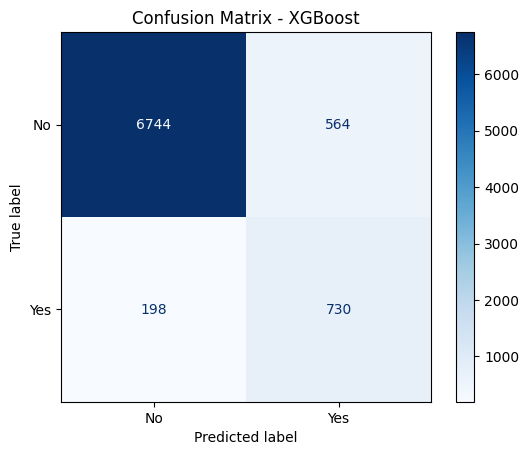

In [207]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_xgb = xgb_model.predict(X_test_processed)

# Confusion Matrix
cm = confusion_matrix(y_test_xgb, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()



The model correctly classified 6,744 non-subscribers and 730 subscribers.

Only 198 actual subscribers were missed (False Negatives), indicating that the model is effective at identifying potential customers who are likely to subscribe.

Although 564 non-subscribers were incorrectly predicted as subscribers (False Positives), this is generally acceptable in a marketing campaign setting, as contacting an additional customer is less costly than missing a potential subscriber.

Overall, the confusion matrix shows that the model achieves a good balance between identifying subscribers and minimizing incorrect predictions.

AUC Score: 0.9448


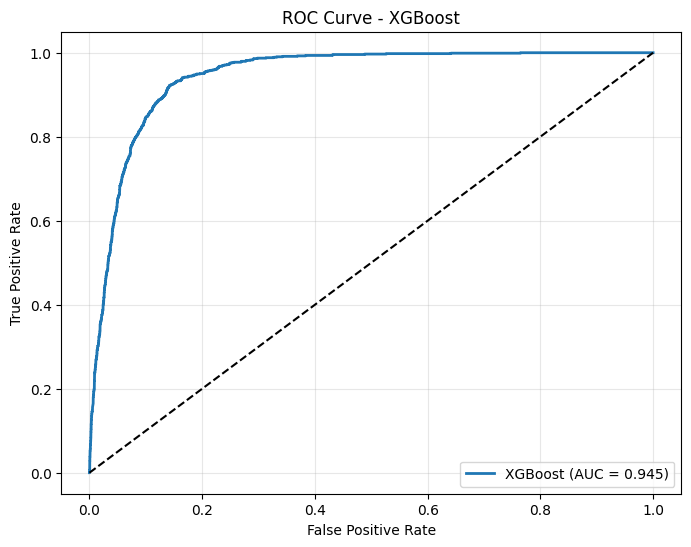

In [208]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob = xgb_model.predict_proba(X_test_processed)[:,1]

# AUC Score
auc = roc_auc_score(y_test_xgb, y_prob)

print(f"AUC Score: {auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_xgb, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2,
         label=f'XGBoost (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Observation

The XGBoost model achieved an AUC score of 0.945, indicating excellent class separation.

The ROC curve remains well above the baseline, showing that the model can effectively distinguish between subscribers and non-subscribers.

In [210]:


feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
4,num__duration,0.294813
3,num__euribor3m,0.171300
1,num__campaign,0.089046
6,cat__job_blue-collar,0.071411
21,cat__poutcome_success,0.059501
19,cat__poutcome_failure,0.057703
0,num__age,0.031619
17,cat__contact_cellular,0.031389
5,cat__job_admin.,0.029977
10,cat__job_retired,0.029288


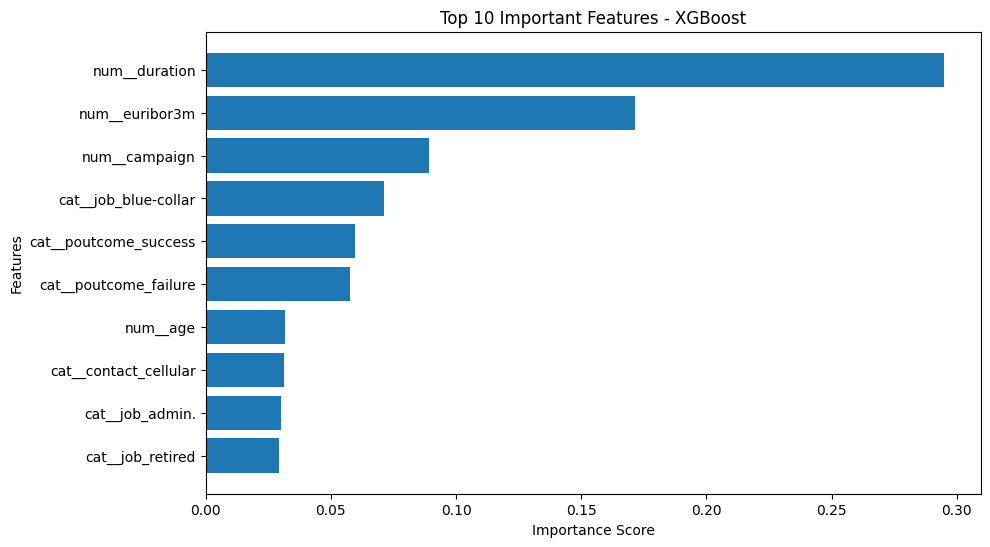

In [211]:

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()


`duration` is the most important feature, followed by `euribor3m` and `campaign`.

This suggests that call-related information, economic conditions, and previous campaign outcomes have the strongest influence on customer subscription predictions.

# Conclusion

This project developed a machine learning model to predict customer subscription to a term deposit.

After data cleaning, feature engineering, preprocessing, and handling class imbalance using SMOTE, four classification models were evaluated. XGBoost achieved the best overall performance and was selected as the final model.

The model demonstrated strong predictive capability with an AUC score of 0.945 and successfully identified a large proportion of potential subscribers.

Feature importance analysis revealed that call duration, economic indicators, and previous campaign information were the most influential factors affecting customer subscription decisions.

Overall, the developed model can help improve customer targeting and support more effective marketing campaigns.